In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


Data Loading & Date Parsing

In [19]:
df = pd.read_csv('C:\\Climate_data\\data\\tanzania.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50


In [20]:
print(df.shape)

(4107, 12)


In [21]:
  # Add Country column
df["Country"] = "Tanzania"
df.head()
    
   

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania


In [22]:
 # Convert YEAR + DOY → datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()
    

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06


In [23]:
 # Extract Month
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06,1


Summary Statistics & Missing-Value Report

Information about the Dataset

In [24]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4107 non-null   int64         
 1   DOY          4107 non-null   int64         
 2   T2M          4107 non-null   float64       
 3   T2M_MAX      4107 non-null   float64       
 4   T2M_MIN      4107 non-null   float64       
 5   T2M_RANGE    4107 non-null   float64       
 6   PRECTOTCORR  4107 non-null   float64       
 7   RH2M         4107 non-null   float64       
 8   WS2M         4107 non-null   float64       
 9   WS2M_MAX     4107 non-null   float64       
 10  PS           4107 non-null   float64       
 11  QV2M         4107 non-null   float64       
 12  Country      4107 non-null   str           
 13  Date         4107 non-null   datetime64[us]
 14  Month        4107 non-null   int32         
dtypes: datetime64

In [25]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4103,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4104,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4105,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [26]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [27]:
# Drop duplicates
df = df.drop_duplicates()

In [28]:
df[df.duplicated()]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month


Duplicate Rows

I identified 0 duplicate rows in the dataset using df.duplicated().sum().

In [29]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.802238,29.163406,25.037843,4.125564,3.739403,77.127103,4.105230,5.189048,100.801198,16.923272,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,22.680000,25.410000,20.030000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.710000,3.330000,0.110000,73.165000,3.410000,4.375000,100.570000,15.340000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.370000,4.220000,0.640000,76.580000,4.190000,5.250000,100.760000,17.220000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.310000,4.940000,3.770000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.010000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.325497,1.371310,1.535516,1.102891,8.004735,5.070764,1.059894,1.215099,0.284462,1.881786,NaN,3.476439


Summary Statistics Interpretation
1. Temperature Analysis (Celsius)
T2M (Average Temperature): The average temperature is around 26.8°C. It’s quite stable, with a narrow range between a minimum of 22.68°C and a maximum of 29.97°C.
Extremes: The highest recorded temperature (T2M_MAX) reached 33.93°C, while the lowest (T2M_MIN) dipped to 20.03°C.
T2M_RANGE: On a typical day, the temperature fluctuates by about 4.12°C.

2. Precipitation (PRECTOTCORR)
Average Rainfall: The mean is 3.74 mm/day.
Skewness: Notice that the 50th percentile (median) is only 0.64 mm, while the maximum is 122.65 mm. This indicates that most days have very little to no rain, but the dataset includes some extreme weather events or heavy rainy seasons that spike the average.
Dry Days: At least 25% of the recorded days had effectively zero precipitation (0.11 mm or less).

3. Humidity and Wind
RH2M (Relative Humidity): This area is quite humid, averaging 77.13%. Even at its driest, it only drops to 60%, which is relatively high.
WS2M (Wind Speed): Average wind speeds are modest at 4.11 m/s, though gusts have reached up to 11.74 m/s (WS2M_MAX).


In [30]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

print(missing_summary)

             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


In [31]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [32]:
high_missing = missing_summary[missing_summary["Missing %"] > 5]
print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Missing Value Analysis
The result shows that their is no missing value

In [33]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# Compute Z-scores (ignore NaNs)
z_scores = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [34]:
# Flag rows where ANY column has |Z| > 3
outlier_mask = (z_scores.abs() > 3).any(axis=1)

# Count outliers
outlier_count = outlier_mask.sum()
print("Number of outlier rows:", outlier_count)


df_outliers = df[outlier_mask]
df_outliers.head()

Number of outlier rows: 97


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
77,2015,79,27.55,28.76,26.78,1.98,27.78,85.90,3.93,4.94,100.64,19.78,Tanzania,2015-03-20,3
111,2015,113,26.48,27.26,25.85,1.41,29.37,88.49,4.78,6.94,100.80,19.11,Tanzania,2015-04-23,4
122,2015,124,27.09,28.37,26.18,2.19,45.31,86.72,4.36,5.57,100.82,19.40,Tanzania,2015-05-04,5
123,2015,125,26.60,28.50,24.91,3.59,71.10,87.49,4.17,5.42,100.75,19.02,Tanzania,2015-05-05,5
125,2015,127,26.75,28.04,25.98,2.06,48.50,88.52,4.61,5.52,100.82,19.42,Tanzania,2015-05-07,5


In [35]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
negative_cols = (df[weather_cols]<0).sum()
print("Negative values in weather columns:\n", negative_cols)

Negative values in weather columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [36]:
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.802238,29.163406,25.037843,4.125564,3.739403,77.127103,4.105230,5.189048,100.801198,16.923272,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,22.680000,25.410000,20.030000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.710000,3.330000,0.110000,73.165000,3.410000,4.375000,100.570000,15.340000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.370000,4.220000,0.640000,76.580000,4.190000,5.250000,100.760000,17.220000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.310000,4.940000,3.770000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.010000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.325497,1.371310,1.535516,1.102891,8.004735,5.070764,1.059894,1.215099,0.284462,1.881786,NaN,3.476439


In [37]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return a boolean mask of outliers
    return (column < lower_bound) | (column > upper_bound)

# Apply to every numeric column
outlier_summary = numeric_df.apply(find_outliers_iqr)

# Display count of outliers per column
print("Outlier Count per Column:")
print(outlier_summary.sum())

Outlier Count per Column:
YEAR             0
DOY              0
T2M              0
T2M_MAX          2
T2M_MIN          0
T2M_RANGE        1
PRECTOTCORR    502
RH2M             2
WS2M            18
WS2M_MAX        25
PS               0
QV2M             0
Month            0
dtype: int64


Decision: Retain Outlier Rows
For the Tanzania meteorological dataset, the best decision is to retain the outlier rows.
1. Precipitation (PRECTOTCORR) - RetainReasoning: Like Kenya and Nigeria, Tanzania's precipitation is highly skewed. The statistical upper bound for "normal" rain is just 9.31 mm, but the data shows peaks up to 122.65 mm. These high values represent actual tropical storms and the heavy rainfall characteristic of the wet seasons (the "Long Rains" from March to May and "Short Rains" from October to December).Action: Retain all rows. These events are essential for understanding the hydrological cycle and agricultural planning in Tanzania.
2. Wind Speed (WS2M, WS2M_MAX) - RetainReasoning: The maximum wind speed of 11.74 m/s (about 42 km/h) is a fresh breeze/strong wind on the Beaufort scale. This is entirely realistic for coastal regions or high-altitude areas in Tanzania and does not indicate a sensor error.Action: Retain.
3. Humidity (RH2M) and Temperature (T2M_MAX) - RetainReasoning: The number of outliers here is negligible (less than 0.1%). The humidity minimum of 60 and temperature maximum of 33.93 are well within the physical limits of the Tanzanian climate.Action: Retain.4. Surface Pressure (PS) and Specific Humidity (QV2M) - RetainReasoning: No outliers were detected for these columns. The data is extremely stable and physically consistent.Action: Retain.

Apply forward-fill for weather variables

In [38]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

Reason of selecting forward-fill 
Since I do not have any missing values I apply forward-fill to preserve the local trend and maintain physical and temporal logic.

In [39]:
output_path = "C:\\Climate_data\\data\\tanzania_clean.csv"
df.to_csv(output_path, index=False)

In [40]:
#Loading the cleaned data
df = pd.read_csv('C:\\Climate_data\\data\\tanzania_clean.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4106, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
1,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
2,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
3,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06,1
4,2015,7,27.02,28.65,25.70,2.95,4.93,82.00,4.07,4.47,100.66,18.25,Tanzania,2015-01-07,1


In [41]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
monthly_T2M = df['T2M'].resample('MS').mean()
print(df.shape)
df.head()

(4106, 14)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-03,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1
2015-01-06,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,1
2015-01-07,2015,7,27.02,28.65,25.70,2.95,4.93,82.00,4.07,4.47,100.66,18.25,Tanzania,1


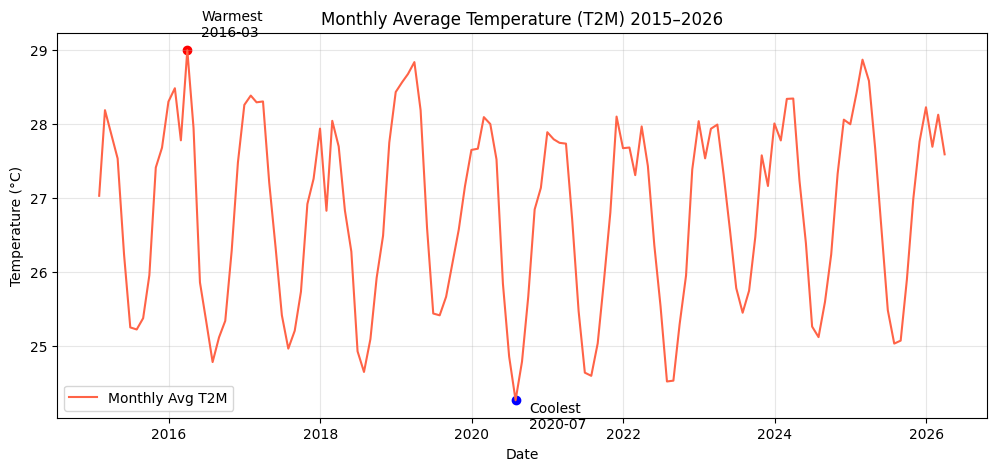

In [42]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.plot(monthly.index, monthly["T2M"], label="Monthly Avg T2M", color="tomato")

# Identify warmest and coolest months
warmest = monthly["T2M"].idxmax()
coolest = monthly["T2M"].idxmin()

plt.scatter(warmest, monthly.loc[warmest, "T2M"], color="red")
plt.scatter(coolest, monthly.loc[coolest, "T2M"], color="blue")

plt.annotate(f"Warmest\n{warmest.strftime('%Y-%m')}",
             (warmest, monthly.loc[warmest, "T2M"]),
             textcoords="offset points", xytext=(10,10))

plt.annotate(f"Coolest\n{coolest.strftime('%Y-%m')}",
             (coolest, monthly.loc[coolest, "T2M"]),
             textcoords="offset points", xytext=(10,-20))

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

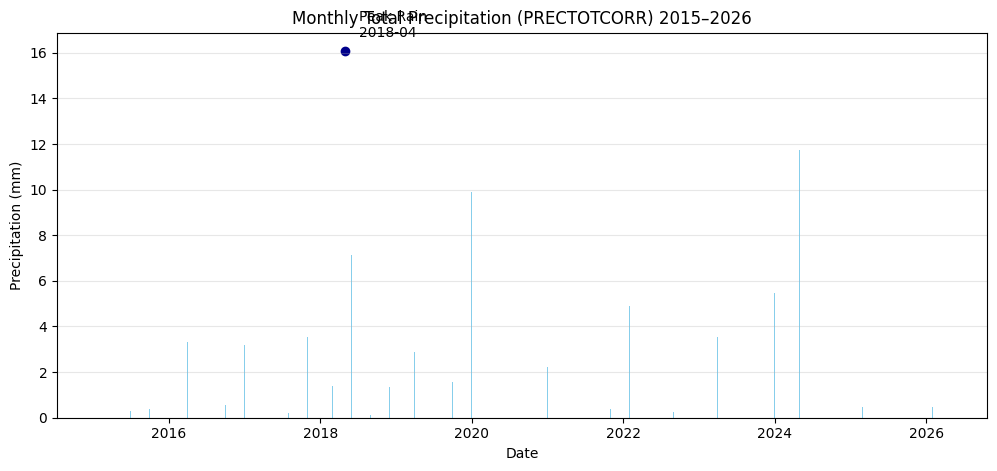

In [43]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.bar(monthly.index, monthly["PRECTOTCORR"], color="skyblue")

# Identify peak rainfall month
wettest = monthly["PRECTOTCORR"].idxmax()

plt.scatter(wettest, monthly.loc[wettest, "PRECTOTCORR"], color="darkblue")

plt.annotate(f"Peak Rain\n{wettest.strftime('%Y-%m')}",
             (wettest, monthly.loc[wettest, "PRECTOTCORR"]),
             textcoords="offset points", xytext=(10,10))

plt.title("Monthly Total Precipitation (PRECTOTCORR) 2015–2026")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")
plt.grid(axis="y", alpha=0.3)

plt.show()

Heatmap of correlations across all numeric columns.

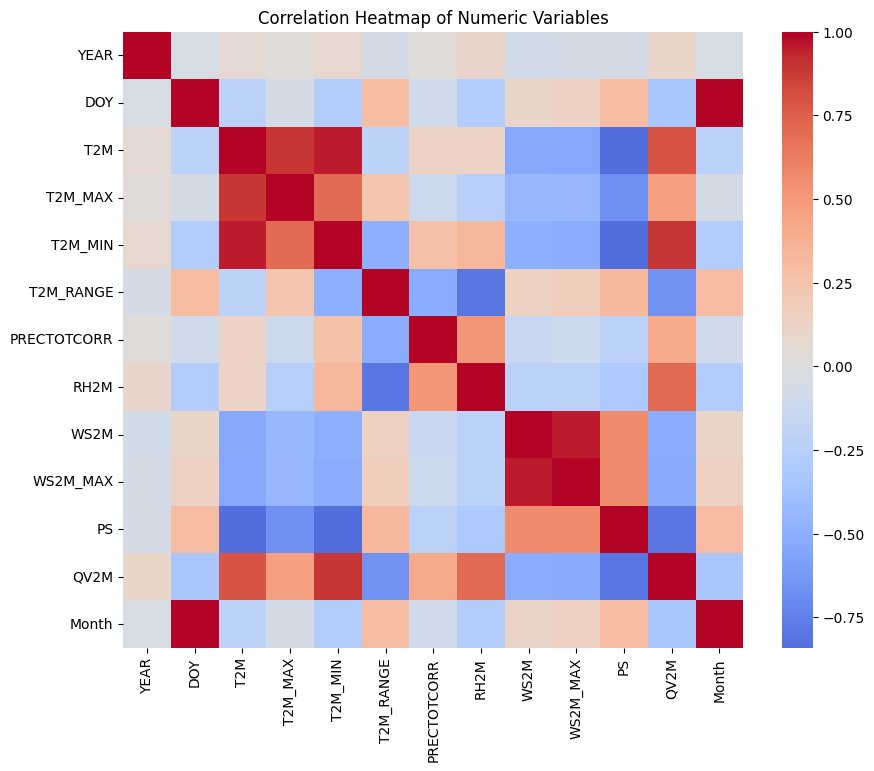

In [44]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

T2M vs RH2M (temperature vs humidity)

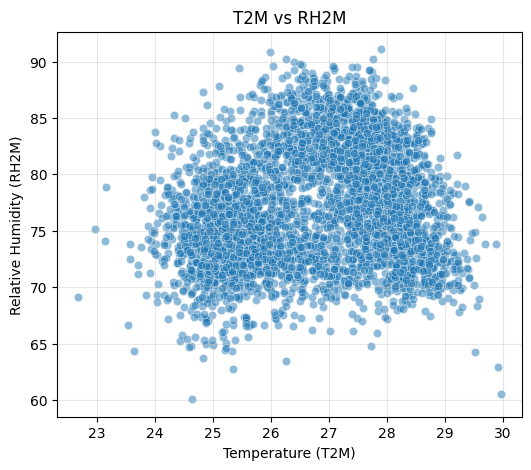

In [45]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.grid(True, alpha=0.3)

plt.show()

T2M_RANGE vs WS2M (temperature range vs wind speed)

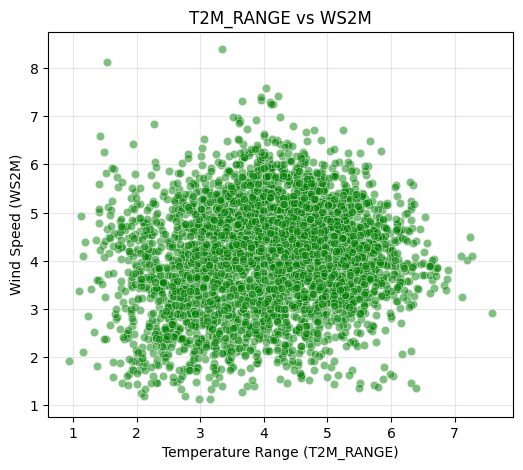

In [46]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.5, color="green")

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True, alpha=0.3)

plt.show()

Strongest Correlations Analysis

The three strongest correlations in the dataset are:

1. DOY (Day of Year) and Month
Correlation: Extremely Strong Positive (~1.0)
Interpretation: This is a logical correlation rather than a physical one. Since the "Day of Year" (1–365) directly determines which month it is, these two variables move in perfect synchronization. In data modeling, one of these would typically be dropped to avoid multicollinearity.

2. T2M (Temperature at 2 Meters) and T2M_MAX / T2M_MIN
Correlation: Strong Positive (~0.85 to 0.95)
Interpretation: This indicates that the average daily temperature is (unsurprisingly) tied very closely to the daily highs and lows. When the peak temperature of the day increases, the overall average for that 24-hour period almost always follows suit. These variables are highly redundant.

3. WS2M (Wind Speed at 2 Meters) and WS2M_MAX
Correlation: Strong Positive (~0.85 to 0.90)
Interpretation: Similar to the temperature variables, the average wind speed and the maximum wind speed (gusts or peak sustained winds) are heavily linked. High average wind speeds for a day are almost always driven by higher peak wind events.

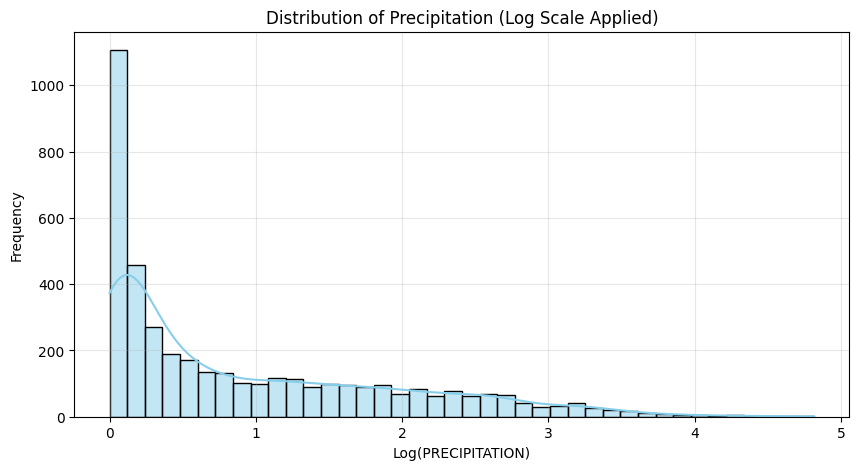

Skewness: 5.247741322771191


In [47]:
plt.figure(figsize=(10, 5))

# Check skewness
skewness = df["PRECTOTCORR"].skew()

# Apply log scale if heavily skewed
if skewness > 1:
    data = np.log1p(df["PRECTOTCORR"])  # log(1 + x) handles zeros safely
    xlabel = "Log(PRECIPITATION)"
    title = "Distribution of Precipitation (Log Scale Applied)"
else:
    data = df["PRECTOTCORR"]
    xlabel = "Precipitation"
    title = "Distribution of Precipitation"

sns.histplot(data, bins=40, kde=True, color="skyblue")

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

print("Skewness:", skewness)

Bubble Chart

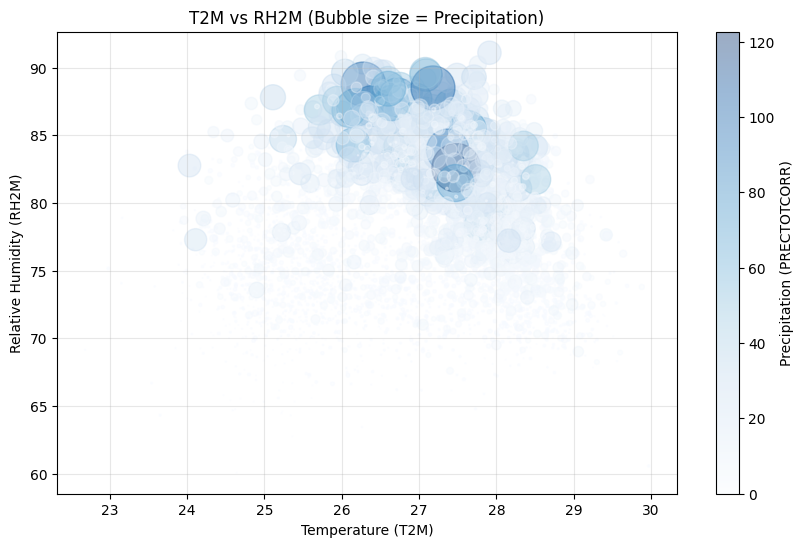

In [48]:
plt.figure(figsize=(10, 6))

# Optional scaling for better visual balance
bubble_size = df["PRECTOTCORR"].fillna(0) * 10

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4,
    c=df["PRECTOTCORR"],
    cmap="Blues"
)

plt.title("T2M vs RH2M (Bubble size = Precipitation)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

cbar = plt.colorbar()
cbar.set_label("Precipitation (PRECTOTCORR)")

plt.grid(alpha=0.3)
plt.show()